In [142]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

## Opgave 6.1

### (a)

Den differentieret funktion af $f(x) = \frac{1}{1+x^{2}}$ vil være:
$$
\begin{align*}
f'(x) & = - \frac{2x}{(1 + x^{2})^{2}}
\end{align*}
$$
hvilket giver konditionstallet:
$$
\begin{align*}
\kappa (x) & = \frac{|x| |f'(x)|}{f(x)} \\
 & = \frac{|x| |-\frac{2x}{(1+x^{2})^{2}}|}{|\frac{1}{1+x^{2}}|} \\
 & = \frac{|\frac{2x^{2}}{(1+x^{2})^{2}}|}{\frac{1}{1+x^{2}}} \\
 & = \frac{2x^{2}}{1+x^{2}}
\end{align*}
$$


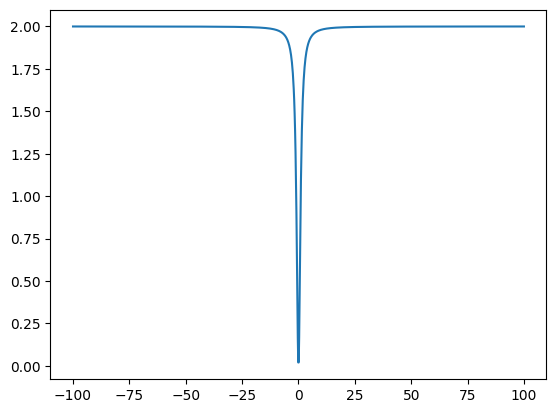

In [140]:
x = np.linspace(-100, 100, 1000)

fig, ax = plt.subplots()
ax.plot(x, (2*x**2)/(1+x**2))

### (b)

Den differentieret funktion af $f(x) = \sin(x)$ vil være:
$$
\begin{align*}
f'(x) & = \cos(x)
\end{align*}
$$
hvilket giver konditionstallet:
$$
\begin{align*}
\kappa (x) & = \frac{|x| |f'(x)|}{f(x)} \\
 & = \frac{|x| |\cos(x)|}{|\sin(x)|}
\end{align*}
$$


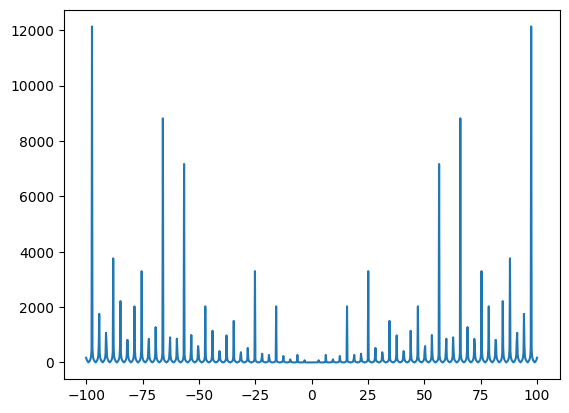

In [141]:
x = np.linspace(-100, 100, 1000)

fig, ax = plt.subplots()
ax.plot(x, (np.abs(x) * np.abs(np.cos(x)))/np.abs(np.sin(x)))

### (c)

Den differentieret funktion af $f(x, y) = xy$ vil gradienten være:
$$
\begin{align*}
\nabla f & = (f_{x}, f_{y})\\
 & = (y, x)
\end{align*}
$$
hvilket giver konditionstallet:
$$
\begin{align*}
\kappa (x) & = \frac{|x| |\nabla f|}{|f(x,y)|} \\
 & = \frac{||(x,y)||_{2} ||(y,x)||_{2}}{|xy|} \\
 & = \frac{\sqrt{ x^{2} + y^{2} } \sqrt{ y^{2} + x^{2} }}{|xy|}\\
 & = \frac{y^{2} + x^{2}}{|xy|}
\end{align*}
$$

## Opgave 6.2

### (a)

$$
\begin{align*}
(3 + 2i) + (-1 + i) & = 2 + 3i
\end{align*}
$$

### (b)

$$
\begin{align*}
(3 + 2i) (-1 + i) & = -3 + 3i - 2i - 2\\
 & = -5 + i
\end{align*}
$$

### (c)

$$
\begin{align*}
(3 + 2i) / (-1 + i) & = (3 + 2i) \cdot \frac{-1 - i}{(-1)^{2} + 1^{2}} \\
 & = \frac{-3 - 3i - 2i + 2}{2} \\
 & = \frac{-1 - 5i}{2}
\end{align*}
$$

### (d)

$$
\begin{align*}
(1 + i) z & = 2 - i \\
 & = (2 - i) \cdot \frac{1 - i}{1^{2} + 1^{2}} \\
 & = \frac{2 - 2i - i - 1}{2} \\
 & = \frac{1 - 3i}{2}
\end{align*}
$$

### (e)

In [25]:
ligning = np.array([[1 - 1j , 1j        , - 1 - 1j, 5 ],
                    [1      , - 2 - 1j  , 1j    , 2 ],
                    [1j     , 1 - 1j    , 1 -1j , 0 ]])

ligning[0] += ligning[2]
ligning[2] -= 1j * ligning[0]
ligning[1] -= ligning[0]
ligning[1] *= 1 / ligning[1, 1]
ligning[2] -= ligning[2,1] * ligning[1]
ligning[2] *= 1 / ligning[2, 2]
ligning[1] -= ligning[1,2] * ligning[2]
ligning[0] -= ligning[0,2] * ligning[2]
ligning[0] -= ligning[0,1] * ligning[1]

print(np.round(ligning, 4))
#print(ligning)

[[ 1.+0.j  0.-0.j  0.-0.j  6.+2.j]
 [-0.+0.j  1.+0.j  0.+0.j  3.+0.j]
 [ 0.+0.j  0.-0.j  1.-0.j  1.-2.j]]


## Opgave 6.3

### (a)

In [20]:
A = np.array([[2, 0],
              [0, 1]], dtype=float)
e0 = np.array([1, 0], dtype=float)[:, np.newaxis]
e1 = np.array([0, 1], dtype=float)[:, np.newaxis]

print(np.vdot(A @ e0, A @ e1))

0.0


### (b)

In [21]:
def angle(v0, v1):
    return np.arccos(np.vdot(v0, v1) / (np.linalg.norm(v0) * np.linalg.norm(v1)))

In [22]:
v0 = np.array([1, 1], dtype=float)[:, np.newaxis]
v1 = np.array([1, -1], dtype=float)[:, np.newaxis]

theta_v0v1 = angle(v0, v1)
theta_Av0Av1 = angle(A @ v0, A @ v1)

print("Vinklen mellem vektorerne: ", np.rad2deg(theta_v0v1))
print("Vinklen mellem matrixproduktet: ", np.rad2deg(theta_Av0Av1))

Vinklen mellem vektorerne:  90.0
Vinklen mellem matrixproduktet:  53.13010235415599


### (c)

[-0.  1.]


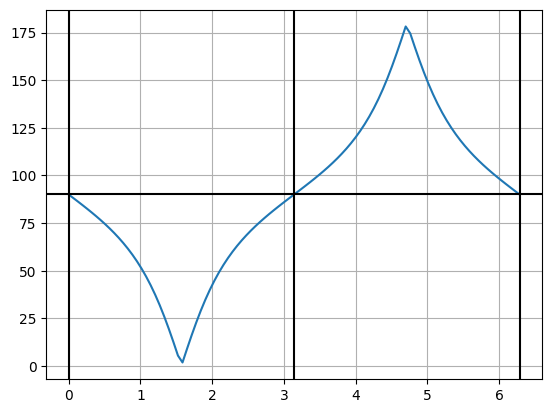

In [109]:
x = np.linspace(0, 2 * np.pi, 100)
w0 = np.array([np.cos(x), np.sin(x)])
w1 = np.array([-np.sin(0), np.cos(0)])
print(w1)

Aw0 = A @ w0
Aw1 = A @ w1

angles = np.zeros((len(x), 1))

for i in range(len(x)):
    angles[i] = np.rad2deg(angle(Aw0[:, i], Aw1[:]))

fig, ax = plt.subplots()
ax.plot(x, angles)
ax.axhline(90, color='black')
for i in range(3):
    ax.axvline(i*np.pi, color='black')
ax.grid()

[-1.000000e+00  6.123234e-17]


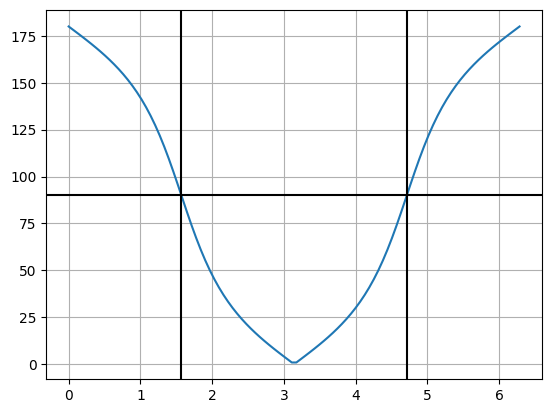

In [108]:
x = np.linspace(0, 2 * np.pi, 100)
w0 = np.array([np.cos(x), np.sin(x)])
w1 = np.array([-np.sin(np.pi/2), np.cos(np.pi/2)])
print(w1)


Aw0 = A @ w0
Aw1 = A @ w1

angles = np.zeros((len(x), 1))

for i in range(len(x)):
    angles[i] = np.rad2deg(angle(Aw0[:, i], Aw1[:]))

fig, ax = plt.subplots()
ax.plot(x, angles)
ax.axhline(90, color='black')
for i in range(1,4,2):
    ax.axvline(i*np.pi/2, color='black')
ax.grid()

## Opgave 6.4

Reference notesæt 12.3

krav for underrum

$w \subset v$
1. $w \neq \emptyset$
    * Underrummet må ikke være tomt. (test ved at finde en funktion der eksisterer og passer til underrummet)
2. $a,b \in W \to a + b \in w$
    * Summen af to funktioner i underrumet skal give endnu en funktion i underummet. (test ved at summere to funktioner i underrummet)
3. $s \in \mathbb{R} , a \in w \to sa \in w$
    * Hvis man skalerer en funktion i underrummet skal det stadig være en funktion i underrummet. (test ved at gange funktion med skalar.)

### (a)

Krav 1.

Der er en funktion der passer i intervallet fx. $f(x) = 0$, så det er ikke den tomme mængde



## Opgave 6.5

### (a)

Da A allerede er en diagonal matrix, vil $\Sigma$ blot være A men sorteret i størrelsesrækkefølge. Derefter skal U og $V^{T}$ blot være fyldt ud med 1'ere, som får $\Sigma$ tilbage til A for at fuldføre ligningen $A = U \Sigma V^{T}$.

Eksemelvis ville disse virke:

In [33]:
A = np.array([  [-2, 0, 0],
                [0, 6, 0],
                [0, 0, 1]])

sigma = np.array([  [6, 0, 0],
                    [0, 1, 0],
                    [0, 0, -2]])

U = np.array([  [0, 0, 1],
                [1, 0, 0],
                [0, 1, 0]])

V = np.array([  [0, 0, 1],
                [1, 0, 0],
                [0, 1, 0]])

U @ sigma @ V.T

array([[-2,  0,  0],
       [ 0,  6,  0],
       [ 0,  0,  1]])

### (b)

In [18]:
A = np.array([  [-2, 0, 0, 0, 0],
                [0, 6, 0, 0, 0],
                [0, 0, 1, 0, 0],
                [0, 0, 0, 3, 0],
                [0, 0, 0, 0, -1]], dtype=float)

U = np.array([  [0, 1, 0, 0, 0],
                [0, 0, 0, 1, 0],
                [0, 0, 1, 0, 0],
                [0, 0, 0, 0, 1],
                [1, 0, 0, 0, 0]], dtype=float)

sigma = U@A@U.T
print(sigma)

U = np.array([  [0, 0, 0, 0, 1],
                [0, 0, 0, 1, 0],
                [0, 0, 1, 0, 0],
                [0, 0, 0, 0, 0],
                [1, 0, 0, 0, 0]], dtype=float)

[[ 6.  0.  0.  0.  0.]
 [ 0.  3.  0.  0.  0.]
 [ 0.  0.  1.  0.  0.]
 [ 0.  0.  0. -1.  0.]
 [ 0.  0.  0.  0. -2.]]


### (c) Givet en vilkårlig $A \in \mathbb{R}^{m \times n}$ og 𝐴 =𝑈Σ𝑉𝑇 en SVD for 𝐴, bestem en SVD for $A^{T}$ .

Bruger proposition 9.4
$$
A = (U \Sigma V^{T})^{T} = V \Sigma U^{T}
$$

### (d)

Siden U og V bare skal være ortogonal, men A allerede er ortogonal kan man definere dem således:
$$
U = A, \qquad \Sigma = I_{n}, \qquad V = I_{n}
$$

### (e)

### (f)